In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Device : cuda
GPU : Tesla T4


100%|██████████| 170M/170M [26:27<00:00, 107kB/s]    


Classes:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Training Images : 50000
Testing Images  : 10000


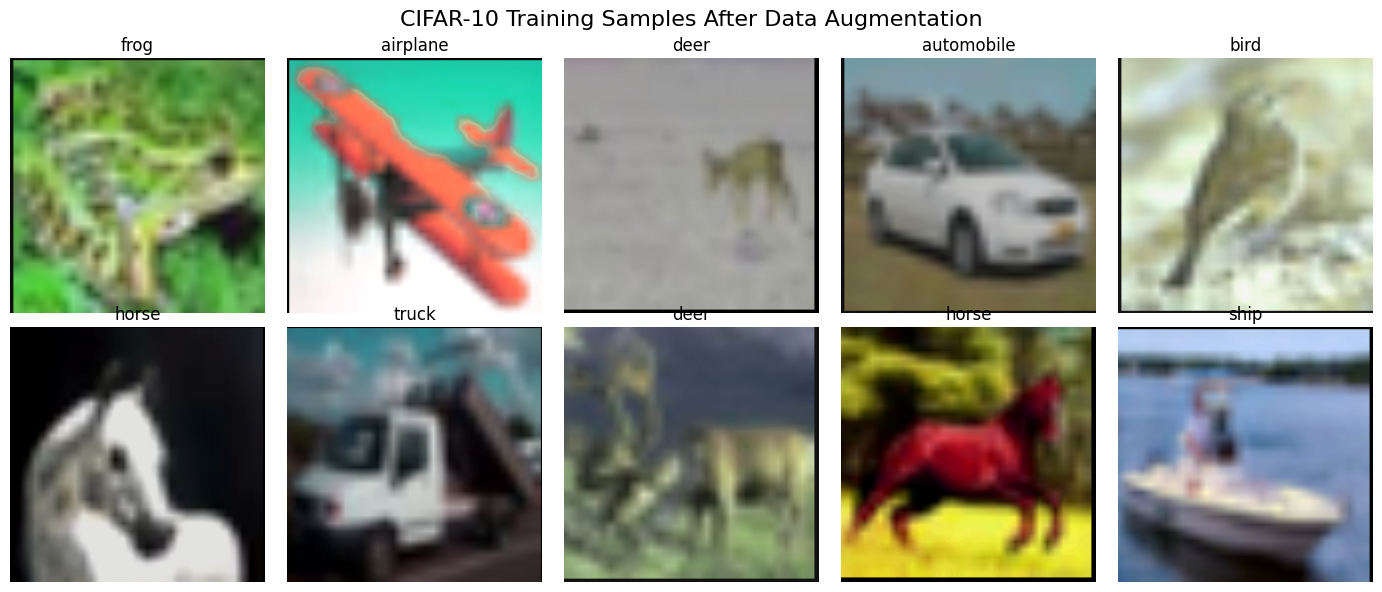

Dataset Summary
Classes          : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Training Images  : 50000
Testing Images   : 10000
Batch Size       : 64
Image Size       : 224


In [2]:
import os
import copy
import random
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights

from torch.utils.data import DataLoader

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tqdm.auto import tqdm

from torchinfo import summary



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 50)
print("Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")
print("=" * 50)


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


os.makedirs("checkpoints", exist_ok=True)
os.makedirs("results", exist_ok=True)


IMAGE_SIZE = 224

BATCH_SIZE = 64

NUM_CLASSES = 10

EPOCHS = 30

LEARNING_RATE = 1e-4

NUM_WORKERS = 2

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]


train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),
    transforms.RandomCrop(IMAGE_SIZE, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=MEAN,
        std=STD
    )
])


test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=MEAN,
        std=STD
    )
])


train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

print("Classes:")
print(train_dataset.classes)

print("\nTraining Images :", len(train_dataset))
print("Testing Images  :", len(test_dataset))

CLASS_NAMES = train_dataset.classes

images, labels = next(iter(train_loader))

mean = torch.tensor(MEAN).view(3,1,1)
std = torch.tensor(STD).view(3,1,1)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i, ax in enumerate(axes.flat):
    img = images[i].cpu() * std + mean
    img = img.permute(1, 2, 0).clamp(0, 1)

    ax.imshow(img)
    ax.set_title(CLASS_NAMES[labels[i]])
    ax.axis("off")

plt.suptitle("CIFAR-10 Training Samples After Data Augmentation",
    fontsize=16)
plt.tight_layout()
plt.show()

print("=" * 50)
print("Dataset Summary")
print("=" * 50)
print(f"Classes          : {CLASS_NAMES}")
print(f"Training Images  : {len(train_dataset)}")
print(f"Testing Images   : {len(test_dataset)}")
print(f"Batch Size       : {BATCH_SIZE}")
print(f"Image Size       : {IMAGE_SIZE}")
print("=" * 50)

In [3]:
# Load pretrained ResNet18
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

for param in model.parameters():
    param.requires_grad = True


num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features,512),
    nn.ReLU(inplace=True),
    nn.BatchNorm1d(512),
    nn.Dropout(0.3),
    nn.Linear(512,NUM_CLASSES)
)
model = model.to(device)
model.train()

summary(
    model,
    input_size=(1,3,IMAGE_SIZE,IMAGE_SIZE),
    device=str(device),
    col_names=[
        "input_size",
        "output_size",
        "num_params",
        "trainable"
    ]
)

trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

total_params = sum(
    p.numel() for p in model.parameters()
)

print(f"Trainable Parameters : {trainable_params:,}")
print(f"Total Parameters     : {total_params:,}")


print("=" * 60)
print("Model Summary")
print("=" * 60)
print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")
print(f"Frozen Parameters    : {total_params-trainable_params:,}")
print("=" * 60)

print("\nModified ResNet18 Architecture:\n")
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 160MB/s] 


Trainable Parameters : 11,445,322
Total Parameters     : 11,445,322
Model Summary
Total Parameters     : 11,445,322
Trainable Parameters : 11,445,322
Frozen Parameters    : 0

Modified ResNet18 Architecture:

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1

In [4]:
# ==========================================================
# TRAINING CONFIGURATION
# ==========================================================

# Loss Function
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

# Mixed Precision Training
scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

# Early Stopping
PATIENCE = 5

best_val_acc = 0.0
patience_counter = 0

best_model_weights = copy.deepcopy(model.state_dict())

# Training History
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "learning_rate": []
}

print("=" * 60)
print("Training Configuration")
print("=" * 60)

print(f"Loss Function      : {criterion.__class__.__name__}")
print(f"Optimizer          : {optimizer.__class__.__name__}")
print(f"Scheduler          : {scheduler.__class__.__name__}")
print(f"Learning Rate      : {LEARNING_RATE}")
print(f"Weight Decay       : 1e-4")
print(f"Epochs             : {EPOCHS}")
print(f"Batch Size         : {BATCH_SIZE}")
print(f"Mixed Precision    : {'Enabled' if torch.cuda.is_available() else 'Disabled'}")
print(f"Early Stopping     : Patience = {PATIENCE}")

print("=" * 60)

Training Configuration
Loss Function      : CrossEntropyLoss
Optimizer          : AdamW
Scheduler          : CosineAnnealingLR
Learning Rate      : 0.0001
Weight Decay       : 1e-4
Epochs             : 30
Batch Size         : 64
Mixed Precision    : Enabled
Early Stopping     : Patience = 5


In [5]:
# ==========================================================
# TRAINING FUNCTION
# ==========================================================

def train_one_epoch(model, dataloader, criterion, optimizer, scaler, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0
    batch_count = 0

    progress_bar = tqdm(
        dataloader,
        desc="Training",
        leave=False
    )

    for images, labels in progress_bar:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type=device.type,
            enabled=torch.cuda.is_available()
        ):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        batch_count += 1

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        progress_bar.set_postfix(
            loss=f"{running_loss/batch_count:.4f}",
            acc=f"{100*correct/total:.2f}%"
        )

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [6]:
# ==========================================================
# VALIDATION FUNCTION
# ==========================================================

def validate_one_epoch(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0
    batch_count = 0

    with torch.no_grad():

        progress_bar = tqdm(
            dataloader,
            desc="Validation",
            leave=False
        )

        for images, labels in progress_bar:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast(
                device_type=device.type,
                enabled=torch.cuda.is_available()
            ):

                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item()
            batch_count += 1

            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            progress_bar.set_postfix(
                loss=f"{running_loss/batch_count:.4f}",
                acc=f"{100*correct/total:.2f}%"
            )

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [7]:
# ==========================================================
# MAIN TRAINING LOOP
# ==========================================================

print("=" * 70)
print("Starting Training...")
print("=" * 70)

start_time = time.time()

for epoch in range(EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler,
        device
    )

    val_loss, val_acc = validate_one_epoch(
        model,
        test_loader,
        criterion,
        device
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["learning_rate"].append(current_lr)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.2f}%")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.2f}%")
    print(f"LR         : {current_lr:.6f}")

    # Save best model
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        best_model_weights = copy.deepcopy(model.state_dict())

        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_acc": best_val_acc
        }

        torch.save(
            checkpoint,
            "checkpoints/best_model.pth"
        )

        patience_counter = 0

        print("✅ Best model saved.")

    else:

        patience_counter += 1

        print(
            f"No improvement ({patience_counter}/{PATIENCE})"
        )

    if patience_counter >= PATIENCE:

        print("\nEarly stopping triggered!")

        break

    # Update learning rate AFTER validation
    scheduler.step()

training_time = time.time() - start_time

print("\n" + "=" * 70)
print("Training Finished")
print("=" * 70)

print(f"Best Validation Accuracy : {best_val_acc:.2f}%")
print(f"Training Time            : {training_time/60:.2f} minutes")

Starting Training...

Epoch [1/30]


Training:   0%|          | 0/782 [00:00<?, ?it/s]

Validation:   0%|          | 0/157 [00:00<?, ?it/s]

Train Loss : 0.9287
Train Acc  : 83.46%
Val Loss   : 0.7047
Val Acc    : 93.16%
LR         : 0.000100
✅ Best model saved.

Epoch [2/30]


Training:   0%|          | 0/782 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/157 [00:00<?, ?it/s]

Train Loss : 0.5127
Train Acc  : 100.00%
Val Loss   : 0.5856
Val Acc    : 96.68%
LR         : 0.000004
No improvement (4/5)

Epoch [28/30]


Training:   0%|          | 0/782 [00:00<?, ?it/s]

Validation:   0%|          | 0/157 [00:00<?, ?it/s]

Train Loss : 0.5127
Train Acc  : 99.99%
Val Loss   : 0.5863
Val Acc    : 96.59%
LR         : 0.000002
No improvement (5/5)

Early stopping triggered!

Training Finished
Best Validation Accuracy : 96.68%
Training Time            : 103.15 minutes


In [8]:

# ==========================================================
# FINAL MODEL EVALUATION
# ==========================================================

print("=" * 70)
print("Loading Best Model")
print("=" * 70)

checkpoint = torch.load(
    "checkpoints/best_model.pth",
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print(f"Best Validation Accuracy : {checkpoint['best_val_acc']:.2f}%")
print(f"Saved at Epoch           : {checkpoint['epoch']}")


Loading Best Model
Best Validation Accuracy : 96.68%
Saved at Epoch           : 23


In [9]:
# ==========================================================
# TEST SET EVALUATION
# ==========================================================

def evaluate_model(model, dataloader, device):

    model.eval()

    predictions = []
    targets = []

    with torch.no_grad():

        progress_bar = tqdm(
            dataloader,
            desc="Evaluating"
        )

        for images, labels in progress_bar:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            predictions.extend(
                predicted.cpu().numpy()
            )

            targets.extend(
                labels.cpu().numpy()
            )

    return np.array(targets), np.array(predictions)

y_true, y_pred = evaluate_model(
    model,
    test_loader,
    device
)

accuracy = (y_true == y_pred).mean() * 100

print("=" * 60)
print(f"Final Test Accuracy : {accuracy:.2f}%")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4
    )
)

report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4
)

with open(
    "results/classification_report.txt",
    "w"
) as f:

    f.write(report)

print("Classification report saved.")

Evaluating:   0%|          | 0/157 [00:00<?, ?it/s]

Final Test Accuracy : 96.69%
              precision    recall  f1-score   support

    airplane     0.9683    0.9770    0.9726      1000
  automobile     0.9799    0.9770    0.9785      1000
        bird     0.9695    0.9540    0.9617      1000
         cat     0.9235    0.9300    0.9268      1000
        deer     0.9702    0.9760    0.9731      1000
         dog     0.9362    0.9390    0.9376      1000
        frog     0.9870    0.9870    0.9870      1000
       horse     0.9838    0.9720    0.9779      1000
        ship     0.9761    0.9790    0.9775      1000
       truck     0.9751    0.9780    0.9765      1000

    accuracy                         0.9669     10000
   macro avg     0.9670    0.9669    0.9669     10000
weighted avg     0.9670    0.9669    0.9669     10000

Classification report saved.


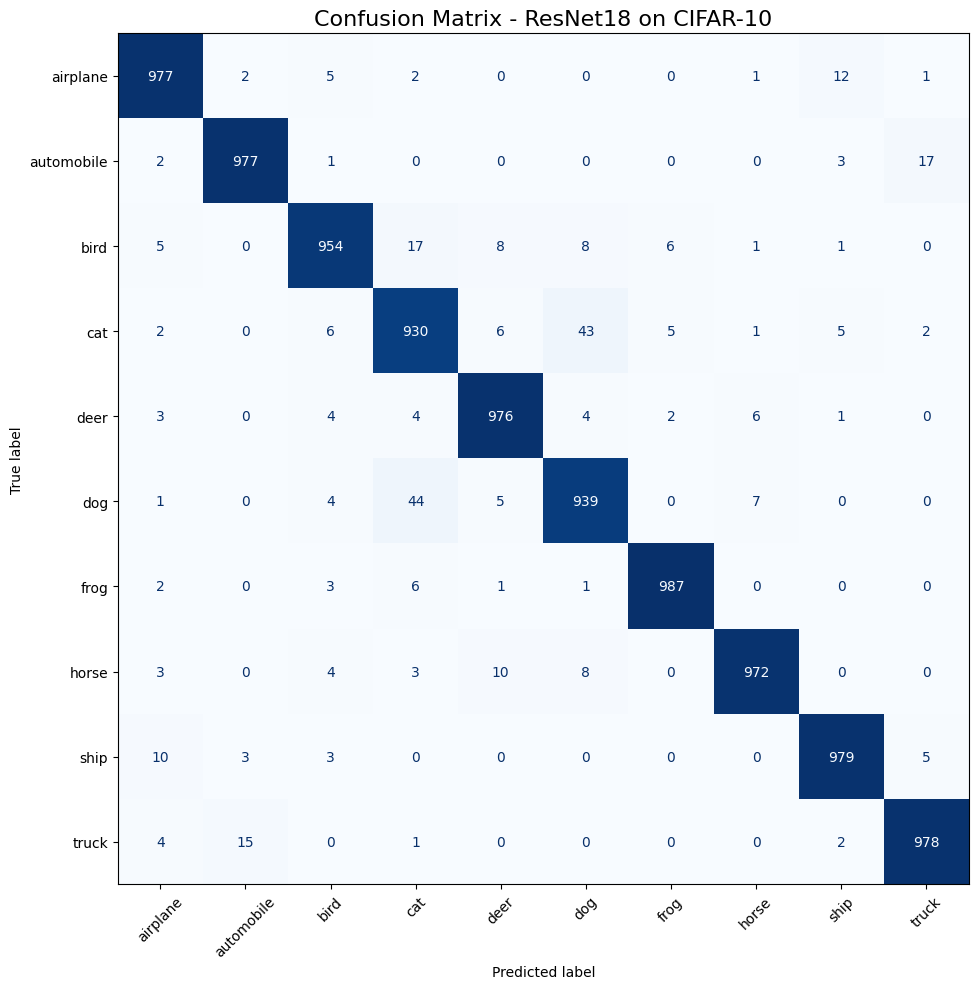

Per-Class Accuracy
airplane     : 97.70%
automobile   : 97.70%
bird         : 95.40%
cat          : 93.00%
deer         : 97.60%
dog          : 93.90%
frog         : 98.70%
horse        : 97.20%
ship         : 97.90%
truck        : 97.80%
Per-class accuracy saved.


In [12]:
# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

fig, ax = plt.subplots(figsize=(10, 10))

disp.plot(
    cmap="Blues",
    ax=ax,
    xticks_rotation=45,
    colorbar=False
)

plt.title(
    "Confusion Matrix - ResNet18 on CIFAR-10",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "results/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



print("=" * 60)
print("Per-Class Accuracy")
print("=" * 60)

for i, class_name in enumerate(CLASS_NAMES):

    accuracy = (
        cm[i, i] /
        cm[i].sum()
    ) * 100

    print(
        f"{class_name:<12} : {accuracy:.2f}%"
    )

with open(
    "results/per_class_accuracy.txt",
    "w"
) as f:

    for i, class_name in enumerate(CLASS_NAMES):

        accuracy = (
            cm[i, i] /
            cm[i].sum()
        ) * 100

        f.write(
            f"{class_name:<12}: {accuracy:.2f}%\n"
        )

print("Per-class accuracy saved.")

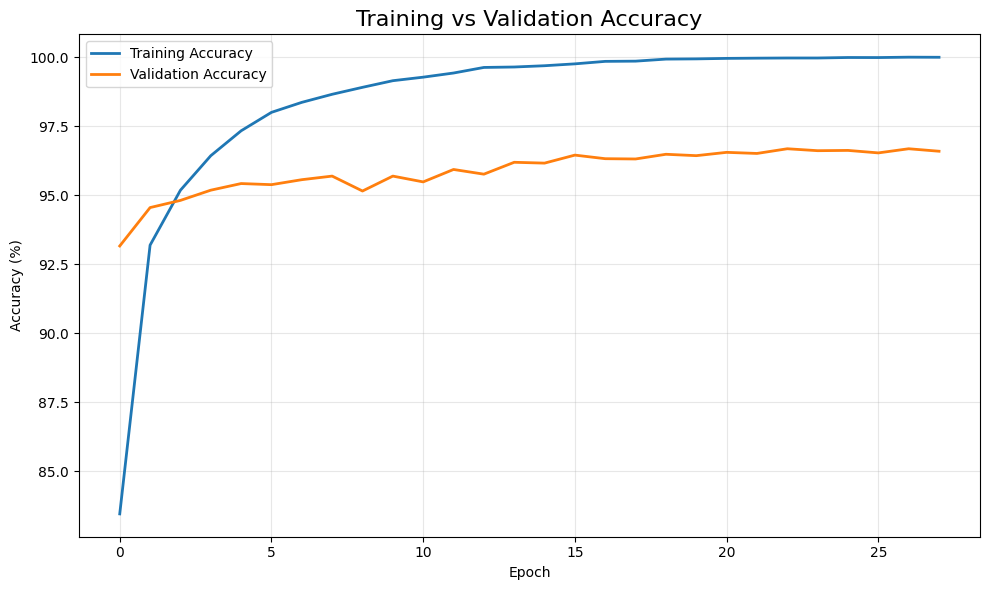

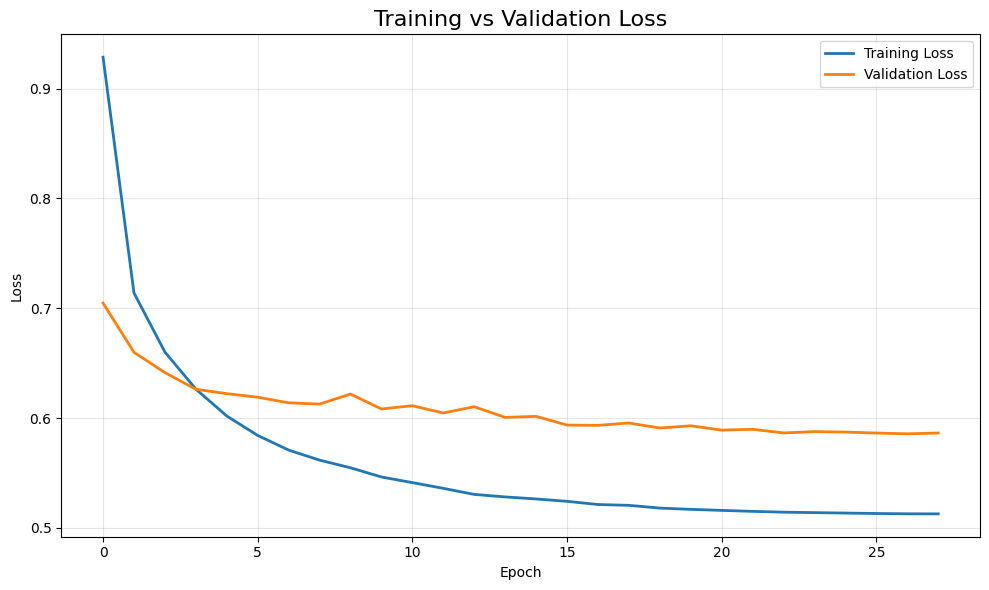

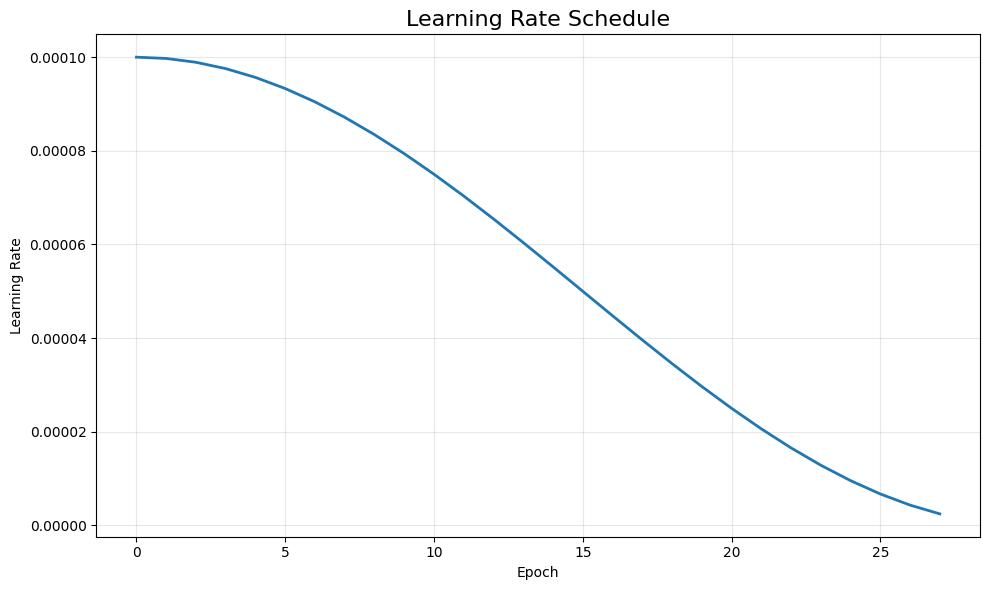

Training Summary
Best Epoch              : 23
Best Validation Accuracy: 96.68%
Final Validation Loss   : 0.5863
Training history saved.


In [14]:
# ==========================================================
# TRAINING VISUALIZATION
# ==========================================================

plt.figure(figsize=(10,6))

plt.plot(
    history["train_acc"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history["val_acc"],
    label="Validation Accuracy",
    linewidth=2
)

plt.title(
    "Training vs Validation Accuracy",
    fontsize=16
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "results/accuracy_curve.png",
    dpi=300
)

plt.show()


plt.figure(figsize=(10,6))

plt.plot(
    history["train_loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.title(
    "Training vs Validation Loss",
    fontsize=16
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "results/loss_curve.png",
    dpi=300
)

plt.show()

plt.figure(figsize=(10,6))

plt.plot(
    history["learning_rate"],
    linewidth=2
)

plt.title(
    "Learning Rate Schedule",
    fontsize=16
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "results/learning_rate_curve.png",
    dpi=300
)

plt.show()


print("="*60)
print("Training Summary")
print("="*60)

best_epoch = np.argmax(history["val_acc"]) + 1

print(f"Best Epoch              : {best_epoch}")
print(f"Best Validation Accuracy: {max(history['val_acc']):.2f}%")
print(f"Final Validation Loss   : {history['val_loss'][-1]:.4f}")

print("="*60)

import pandas as pd

history_df = pd.DataFrame(history)

history_df.to_csv(
    "results/training_history.csv",
    index=False
)

print("Training history saved.")